Stuart Rossiter, C00284845

# Licensing
Convolutional Neural Network using the Cards Image Dataset-Classification Copyright (C) 2025 Stuart Rossiter 
https://www.kaggle.com/datasets/gpiosenka/cards-image-datasetclassification

This program is free software: you can redistribute it and/or modify it under the terms of the GNU General Public License as published by the Free Software Foundation, either version 3 of the License, or (at your option) any later version.

This program is distributed in the hope that it will be useful, but WITHOUT ANY WARRANTY; without even the implied warranty of MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE. See the GNU General Public License for more details.

You should have received a copy of the GNU General Public License along with this program. If not, see https://www.gnu.org/licenses/.

# Convolutional Neural Networks - Playing Card Detection
Using a Convolutional Neural Network, I will be training a model to recognise playing cards, and differentiate between the different suits and ranks.

# Preprocessing
First things first, the data must be imported, and split into the train, test, and validation sets.

In [1]:
import pandas as pd

all = pd.read_csv("cards.csv")

train_df = all[all["data set"] == "train"]
test_df  = all[all["data set"] == "test"]
valid_df = all[all["data set"] == "valid"]

X_train = train_df["filepaths"]
y_train = train_df["labels"]

X_test = test_df["filepaths"]
y_test = test_df["labels"]

X_valid = valid_df["filepaths"]
y_valid = valid_df["labels"]

resolution = (224, 224)
batch_size = 32

This only imports the filenames and the classifier, so we need to create image data from these filepaths. We'll be using Tensorflow's Keras for the model creation, so we'll use their ImageDataGenerator, too.

In [2]:
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(rescale=1./255)

train_gen = datagen.flow_from_dataframe(
    train_df,
    x_col="filepaths",
    y_col="labels",
    target_size=resolution,
    batch_size=batch_size,
    class_mode="categorical"
)

val_gen = datagen.flow_from_dataframe(
    valid_df,
    x_col="filepaths",
    y_col="labels",
    target_size=resolution,
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False
)

test_gen = datagen.flow_from_dataframe(
    test_df,
    x_col="filepaths",
    y_col="labels",
    target_size=resolution,
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False
)

Found 7624 validated image filenames belonging to 53 classes.
Found 265 validated image filenames belonging to 53 classes.
Found 265 validated image filenames belonging to 53 classes.


C:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\legacy\preprocessing\image.py:918: UserWarning: Found 1 invalid image filename(s) in x_col="filepaths". These filename(s) will be ignored.
  warnings.warn(


# Creating the model structure
Before fitting, we need to define the layers of our CNN. We create a sequential model, meaning the layers are stacked one after another, linearly.
Sets of Convolution Layers and Pooling Layers are used, 4 sets to be exact. Convolution Layers extract features from the images, and Pooling Layers downsize the images so features can be detected at a variety of resolutions.
Finally, we flatten the output to a 1D vector, and pass it through 2 Dense layers. These Dense layers are what perform the classification.

In [4]:
from keras import Sequential
from keras.layers import Conv2D, Flatten, Dense, MaxPooling2D

model = Sequential()

model.add(Conv2D(32, (3,3), activation="relu", input_shape=(224, 224, 3)))
model.add(MaxPooling2D())

model.add(Conv2D(128, (3,3), activation="relu"))
model.add(MaxPooling2D())

model.add(Conv2D(128, (3,3), activation="relu"))
model.add(MaxPooling2D())

model.add(Conv2D(128, (3,3), activation="relu"))
model.add(MaxPooling2D())

model.add(Flatten())
model.add(Dense(128, "relu"))
model.add(Dense(len(train_gen.class_indices), "softmax"))
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

model.summary()

C:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)                    │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 109, 109, 128)       │          36,992 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 54, 54, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 52, 52, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 24, 24, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 12, 12, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 18432)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │       2,359,424 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 53)                  │           6,837 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,699,317 (10.30 MB)

 Trainable params: 2,699,317 (10.30 MB)

 Non-trainable params: 0 (0.00 B)

# Training the Convolutional Neural Network

With our model set up, and our data in the correct format, it's finally time to train the CNN. We'll supply it with the training and validation image data, and train it over 10 epochs. An epoch is an iteration over the X and Y data provided, so the data will all be iterated over 10 times. Training the model may take some time as a result.

In [5]:
train_mod = model.fit(train_gen, validation_data=val_gen, epochs=10)

Epoch 1/10
239/239 ━━━━━━━━━━━━━━━━━━━━ 190s 787ms/step - accuracy: 0.2737 - loss: 2.8233 - val_accuracy: 0.5472 - val_loss: 1.4469
Epoch 2/10
239/239 ━━━━━━━━━━━━━━━━━━━━ 179s 748ms/step - accuracy: 0.6003 - loss: 1.5139 - val_accuracy: 0.7547 - val_loss: 0.9600
Epoch 3/10
239/239 ━━━━━━━━━━━━━━━━━━━━ 187s 784ms/step - accuracy: 0.7444 - loss: 0.9308 - val_accuracy: 0.8038 - val_loss: 0.8146
Epoch 4/10
239/239 ━━━━━━━━━━━━━━━━━━━━ 210s 879ms/step - accuracy: 0.8555 - loss: 0.5198 - val_accuracy: 0.8075 - val_loss: 1.0040
Epoch 5/10
239/239 ━━━━━━━━━━━━━━━━━━━━ 219s 918ms/step - accuracy: 0.9227 - loss: 0.2873 - val_accuracy: 0.8000 - val_loss: 1.1738
Epoch 6/10
239/239 ━━━━━━━━━━━━━━━━━━━━ 218s 911ms/step - accuracy: 0.9506 - loss: 0.2027 - val_accuracy: 0.8151 - val_loss: 1.0297
Epoch 7/10
239/239 ━━━━━━━━━━━━━━━━━━━━ 220s 919ms/step - accuracy: 0.9736 - loss: 0.1124 - val_accuracy: 0.8038 - val_loss: 1.1943
Epoch 8/10
239/239 ━━━━━━━━━━━━━━━━━━━━ 218s 913ms/step - accuracy: 0.9793 -

With the model finally trained, we can start making predictions. Before that though, we will plot the accuracy against epochs on a graph.

[]

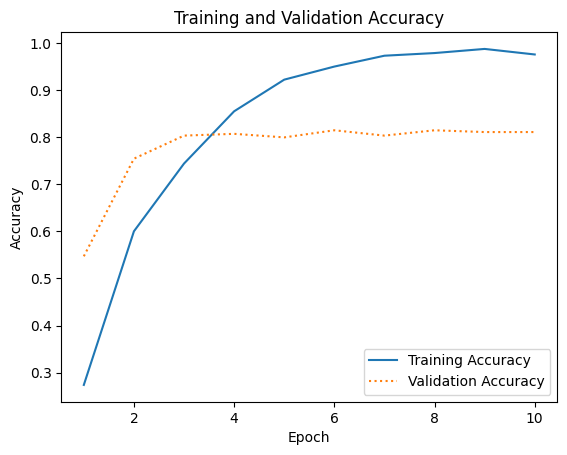

In [6]:
acc = train_mod.history['accuracy']
val_acc = train_mod.history['val_accuracy']
epochs = range(1, len(acc) + 1)

import matplotlib.pyplot as plt

plt.plot(epochs, acc, '-', label='Training Accuracy')
plt.plot(epochs, val_acc, ':', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.plot()

As we can see, the training accuracy peaks around epoch 9, at ~98%. The validation accuracy, on the other hand, peaks at ~80% at epoch 6.

# Prediction
Using our test set, let's predict the card type using our model. The results will be fit to a confusion matrix, maxing out at 20x20 for clarity's sake.

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 152ms/step


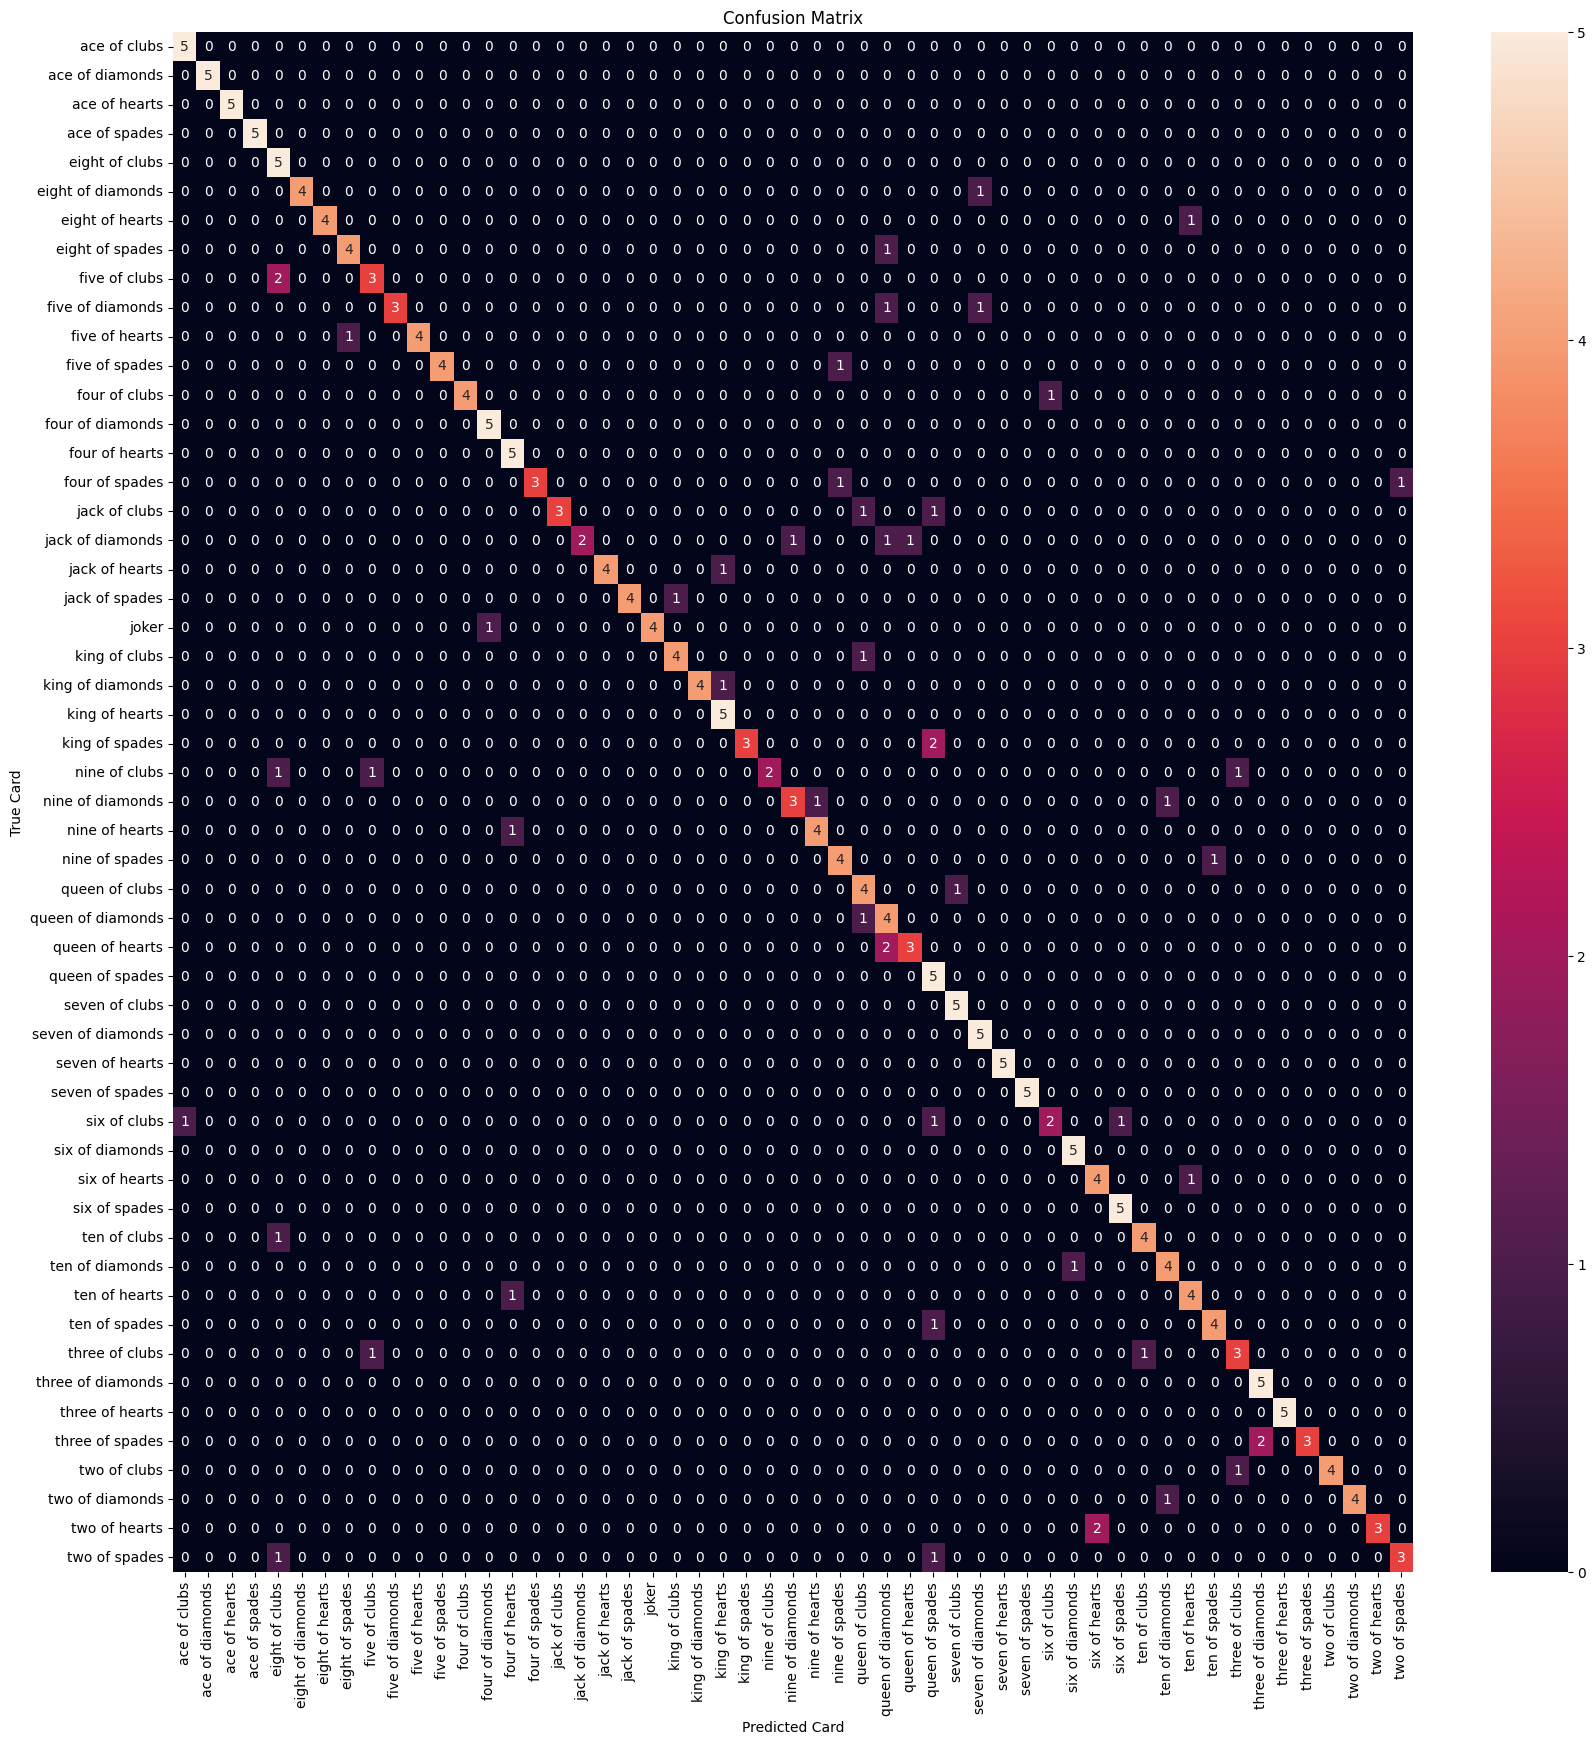

In [7]:
from sklearn.metrics import confusion_matrix
import seaborn as sb
import numpy as np

predictions = model.predict(test_gen)
true_labels = test_gen.classes
predicted_labels = np.argmax(predictions, axis=1)

cm = confusion_matrix(true_labels, predicted_labels)
plt.figure(figsize=(20, 20))
sb.heatmap(cm, annot=True, fmt="d",
            xticklabels=train_gen.class_indices.keys(),
            yticklabels=train_gen.class_indices.keys())
plt.ylabel("True Card")
plt.xlabel("Predicted Card")
plt.title("Confusion Matrix")
plt.show()

We can see a solid diagonal line, which is exactly what we were hoping for. Some incorrect categorisations here and there, but it was highly unlikely the model would be perfect.

# Conclusion
While the accuracy of the model is in the realms of 80-90%, this is not considered adequate for real world applications. If a model of such accuracy were to be used in medical anomaly detection software, the accuracy would need to be near 100%, as people's lives depend on it. For the purpose of identifying playing cards, though? This is a very reasonable model.